---
format: 
    html:
        embed-resources: true
---


# Un-supervised Learning: Analysis of Net Positions, Revenues, Expenses, and Debts (USD) on Number of Subway Trips Made On Time


# Introduction and Motivation:
This section is about the application of un-supervised learning on the Debts (USD) generated from 2019 to 2023 from the MBTA transit system. 
Un-supervised learning is when the data do not have labels and the goal is to see if there are hidden patterns or insights in the dataset
With the application of un0supervised learning, we hope to find trends and patterns in the groups of the debts dataset.

## Data Preprocessing


In [33]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


#import Scikit-learn modules
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [34]:
#load merged net position financial csv file dataset for eda
netposition_dataset = pd.read_csv("../../data/processed-data/Net_positions_reliability_binary.csv")
#convert csv file into a dataframe
netposition_df = pd.DataFrame(netposition_dataset)
#print first few rows of dataframe
print(netposition_df.head())
#print columns of dataframe
print(netposition_df.columns)


#load merged revenue financial csv file dataset for eda
revenue_dataset = pd.read_csv("../../data/processed-data/Revenue_reliability_binary.csv")
#convert csv file into a dataframe
revenue_df = pd.DataFrame(revenue_dataset)
#print first few rows of dataframe
print(revenue_df.head())
#print columns of dataframe
print(revenue_df.columns)


#load merged expenses financial csv file dataset for eda
expenses_dataset = pd.read_csv("../../data/processed-data/Expenses_reliability_binary.csv")
#convert csv file into a dataframe
expenses_df = pd.DataFrame(expenses_dataset)
#print first few rows of dataframe
print(expenses_df.head())
#print columns of dataframe
print(expenses_df.columns)


#load merged debts financial csv file dataset for eda
debts_dataset = pd.read_csv("../../data/processed-data/Debts_reliability_binary.csv")
#convert csv file into a dataframe
debts_df = pd.DataFrame(debts_dataset)
#print first few rows of dataframe
print(debts_df.head())
#print columns of dataframe
print(debts_df.columns)

   Unnamed: 0 Statements of Revenue, Expenses and Changes in Net Position  \
0           0                        Revenue from transportation            
1           1                           Total operating revenues            
2           2                            Transportation services            
3           3                           Other operating expenses            
4           4   Total operating expenses, excluding depreciation            

         Date  Net Position Amounts (USD)  ontime_trip_count  trip_count  \
0  2023-06-30                      376357               2925        3297   
1  2023-06-30                      452973               2925        3297   
2  2023-06-30                      822671               2925        3297   
3  2023-06-30                      968312               2925        3297   
4  2023-06-30                     1790983               2925        3297   

          Time  Pre and Post 2021  Pre and Post 2021 Binary  
0  04:00:00+00    

## Part 1: Dimensionality Reduction

### PCA (Principal Component Analysis):

In [35]:
#drop unneeded columns
netposition_df_drop = netposition_df.drop(["Unnamed: 0", "Pre and Post 2021"],axis=1)
revenue_df_drop = revenue_df.drop(["Unnamed: 0", "Pre and Post 2021"],axis=1)
expenses_df_drop = expenses_df.drop(["Unnamed: 0", "Pre and Post 2021"],axis=1)
debts_df_drop = debts_df.drop(["Unnamed: 0", "Pre and Post 2021"],axis=1)

In [36]:
#subset the net position data, select numerical feature
X_netposition = netposition_df_drop.select_dtypes(include=[np.number])
print(X_netposition.head())

   Net Position Amounts (USD)  ontime_trip_count  trip_count  \
0                      376357               2925        3297   
1                      452973               2925        3297   
2                      822671               2925        3297   
3                      968312               2925        3297   
4                     1790983               2925        3297   

   Pre and Post 2021 Binary  
0                         1  
1                         1  
2                         1  
3                         1  
4                         1  


In [37]:
#subset the revenue data, select numerical feature
X_rev = revenue_df_drop.select_dtypes(include=[np.number])
print(X_rev.columns)

Index(['Revenue (USD)', 'ontime_trip_count', 'trip_count',
       'Pre and Post 2021 Binary'],
      dtype='object')


In [38]:
#subset the expenses data, select numerical feature
X_exp = expenses_df_drop.select_dtypes(include=[np.number])
print(X_exp.columns)

Index(['Expenses (USD)', 'ontime_trip_count', 'trip_count',
       'Pre and Post 2021 Binary'],
      dtype='object')


In [39]:
#subset the expenses data, select numerical feature
X_debts = debts_df_drop.select_dtypes(include=[np.number])
print(X_debts.columns)

Index(['Debt (USD)', 'ontime_trip_count', 'trip_count',
       'Pre and Post 2021 Binary'],
      dtype='object')


In [40]:
#standardize the net position data
#pca reduces data dimensionality by fitting PCA model and transforming X 
scaler = StandardScaler()
X_netposition_scaled = scaler.fit_transform(X_netposition)

#Fit PCA to the standardized net position dataset
pca = PCA(n_components=4) #4 features
X_netposition_pca = pca.fit_transform(X_netposition_scaled)


In [41]:
#standardize the revenue data
#pca reduces data dimensionality by fitting PCA model and transforming X 
X_rev_scaled = scaler.fit_transform(X_rev)

#Fit PCA to the standardized net position dataset
pca_rev = PCA(n_components=4) #4 features
X_rev_pca = pca_rev.fit_transform(X_rev_scaled)


In [42]:
#standardize the expenses data
#pca reduces data dimensionality by fitting PCA model and transforming X 
X_exp_scaled = scaler.fit_transform(X_exp)

#Fit PCA to the standardized net position dataset
pca_exp = PCA(n_components=4) #4 features
X_exp_pca = pca_exp.fit_transform(X_exp_scaled)


In [43]:
#standardize the expenses data
#pca reduces data dimensionality by fitting PCA model and transforming X 
X_debts_scaled = scaler.fit_transform(X_debts)

#Fit PCA to the standardized net position dataset
pca_debts = PCA(n_components=4) #4 features
X_debts_pca = pca_debts.fit_transform(X_debts_scaled)

Explained variance ratio net position dataset:  [0.60435545 0.23362566 0.15930919 0.00270969]
Total explained variance net position dataset:  [0.60435545 0.83798111 0.99729031 1.        ]


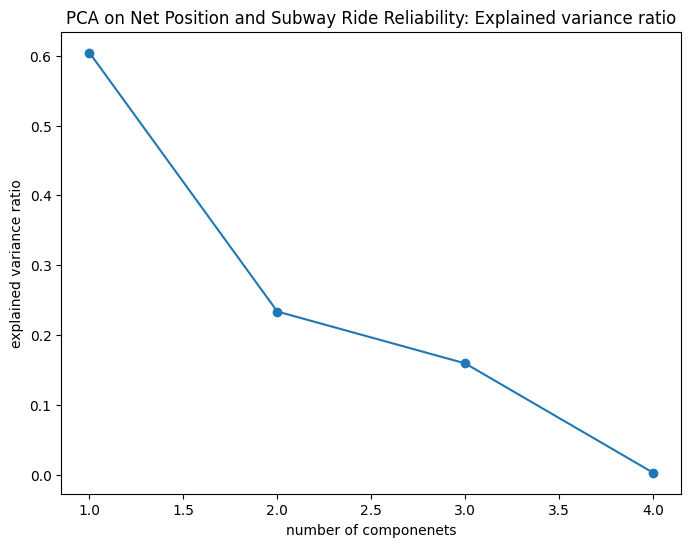

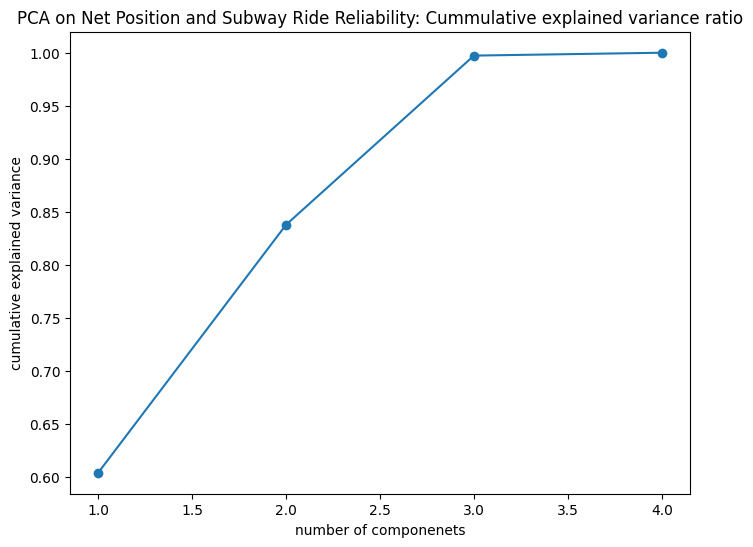

In [53]:
#code re-used from DSAN 5000 lab 4.2
#net position dataset

#get explained variance ratio
net_evr = pca.explained_variance_ratio_
net_tevr = np.cumsum(pca.explained_variance_ratio_)
print("Explained variance ratio net position dataset: ", net_evr)

#get total variance explained
print("Total explained variance net position dataset: ", net_tevr)

#create scatter plot that visualized the number of components and explained variance ratio to find optimal number of principal componenets 
plt.figure(figsize=(8,6)) #set plot size
plt.plot(np.arange(1, len(net_evr) + 1), net_evr, marker='o') #plot pca.explained_variance_ratio, set the x-axis value as array of integers
plt.title("PCA on Net Position and Subway Ride Reliability: Explained variance ratio")
plt.xlabel("number of componenets") #set x-axis label
plt.ylabel("explained variance ratio") #set y-axis label
plt.show() #show plot

#create scatter plot to visualize cummulative explained variance
plt.figure(figsize=(8,6)) #set plot size
plt.plot(np.arange(1,len(net_tevr) + 1), net_tevr, marker='o') #plot np.cumsum(pca.explained_variance_ratio_), set the x-axis value as array of integers
plt.title("PCA on Net Position and Subway Ride Reliability: Cummulative explained variance ratio")
plt.xlabel("number of componenets") #set x-axis label
plt.ylabel("cumulative explained variance") #set y-axis label
plt.show() #show plot


Explained variance ratio:  [0.57747761 0.25691962 0.16257182 0.00303095]
Total explained variance [0.57747761 0.83439723 0.99696905 1.        ]


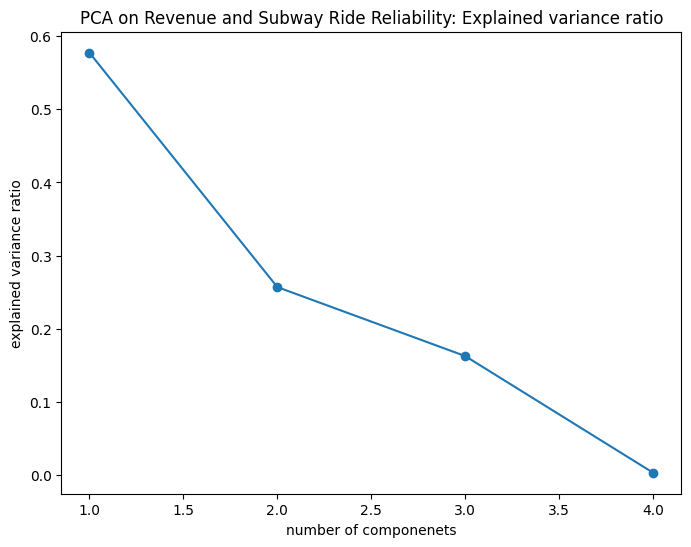

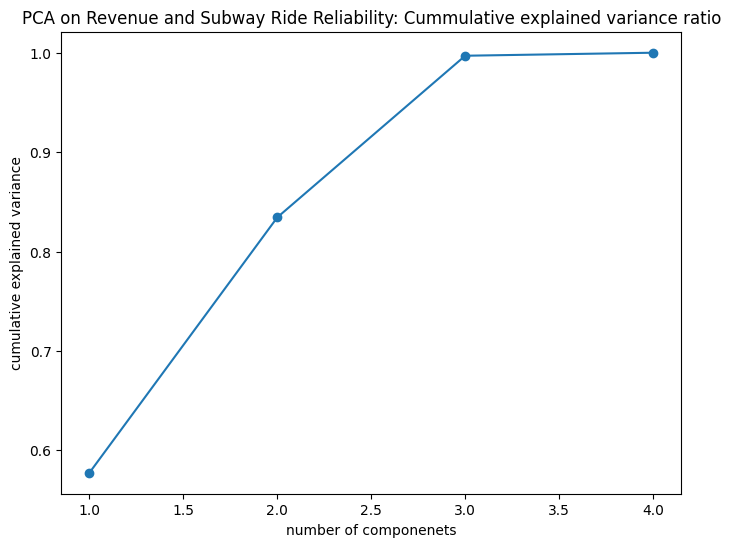

In [51]:
#code re-used from DSAN 5000 lab 4.2
#revenue dataset
#get explained variance ratio
rev_evr =  pca_rev.explained_variance_ratio_
rev_tevr = np.cumsum(pca_rev.explained_variance_ratio_)
print("Explained variance ratio: ",rev_evr)

#get total variance explained
print("Total explained variance", rev_tevr)

#create scatter plot that visualized the number of components and explained variance ratio to find optimal number of principal componenets 
plt.figure(figsize=(8,6)) #set plot size
plt.plot(np.arange(1, len(rev_evr) + 1), rev_evr, marker='o') #plot pca.explained_variance_ratio, set the x-axis value as array of integers
plt.title("PCA on Revenue and Subway Ride Reliability: Explained variance ratio")
plt.xlabel("number of componenets") #set x-axis label
plt.ylabel("explained variance ratio") #set y-axis label
plt.show() #show plot

#create scatter plot to visualize cummulative explained variance
plt.figure(figsize=(8,6)) #set plot size
plt.plot(np.arange(1,len(rev_tevr) + 1), rev_tevr, marker='o') #plot np.cumsum(pca.explained_variance_ratio_), set the x-axis value as array of integers
plt.title("PCA on Revenue and Subway Ride Reliability: Cummulative explained variance ratio")
plt.xlabel("number of componenets") #set x-axis label
plt.ylabel("cumulative explained variance") #set y-axis label
plt.show() #show plot

Explained variance ratio:  [0.58814127 0.24983423 0.1593151  0.00270939]
Total explained variance [0.58814127 0.83797551 0.99729061 1.        ]


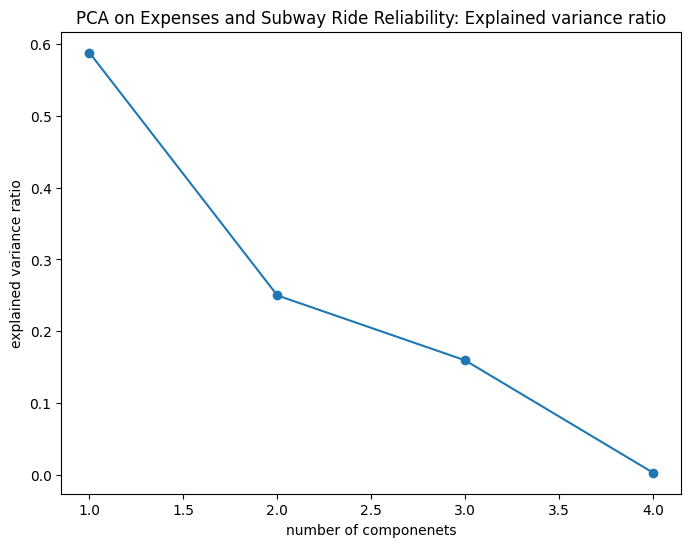

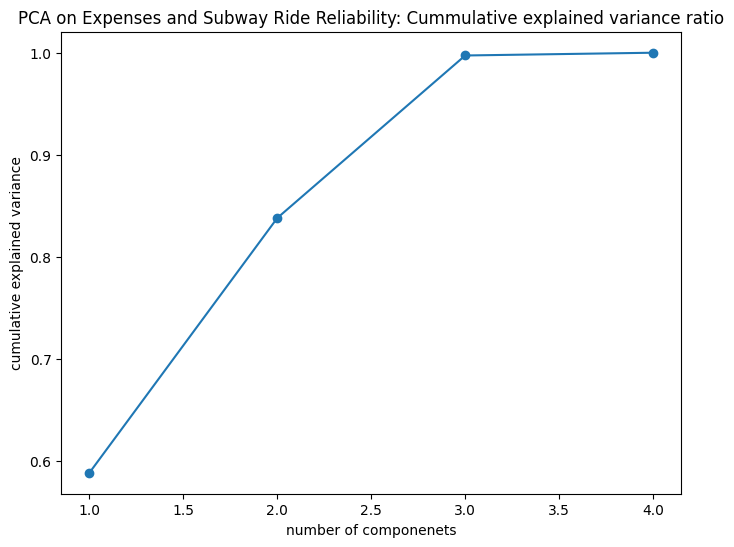

In [50]:
#code re-used from DSAN 5000 lab 4.2
#expenses dataset
#get explained variance ratio
exp_evr = pca_exp.explained_variance_ratio_
exp_tevr = np.cumsum(pca_exp.explained_variance_ratio_)
print("Explained variance ratio: ",exp_evr)

#get total variance explained
print("Total explained variance", exp_tevr)

#create scatter plot that visualized the number of components and explained variance ratio to find optimal number of principal componenets 
plt.figure(figsize=(8,6)) #set plot size
plt.plot(np.arange(1, len(exp_evr) + 1), exp_evr, marker='o') #plot pca.explained_variance_ratio, set the x-axis value as array of integers
plt.title("PCA on Expenses and Subway Ride Reliability: Explained variance ratio")
plt.xlabel("number of componenets") #set x-axis label
plt.ylabel("explained variance ratio") #set y-axis label
plt.show() #show plot

#create scatter plot to visualize cummulative explained variance
plt.figure(figsize=(8,6)) #set plot size
plt.plot(np.arange(1,len(exp_tevr) + 1), exp_tevr, marker='o') #plot np.cumsum(pca.explained_variance_ratio_), set the x-axis value as array of integers
plt.title("PCA on Expenses and Subway Ride Reliability: Cummulative explained variance ratio")
plt.xlabel("number of componenets") #set x-axis label
plt.ylabel("cumulative explained variance") #set y-axis label
plt.show() #show plot

Explained variance ratio:  [6.17549998e-01 2.30211007e-01 1.52222417e-01 1.65787771e-05]
Total explained variance [0.61755    0.847761   0.99998342 1.        ]


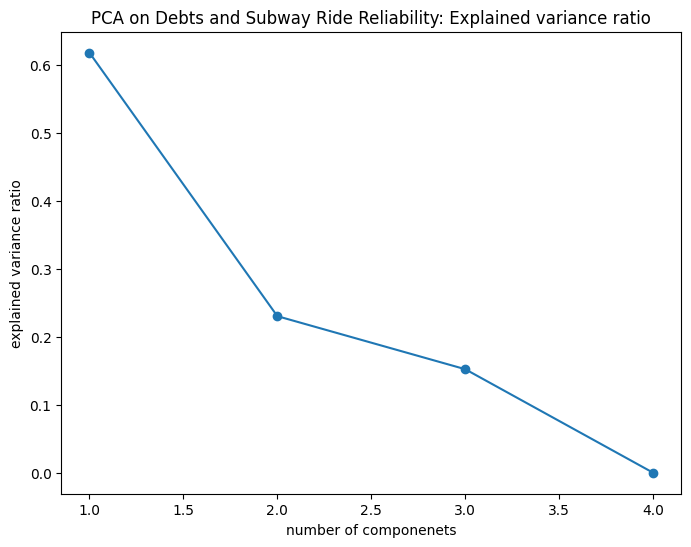

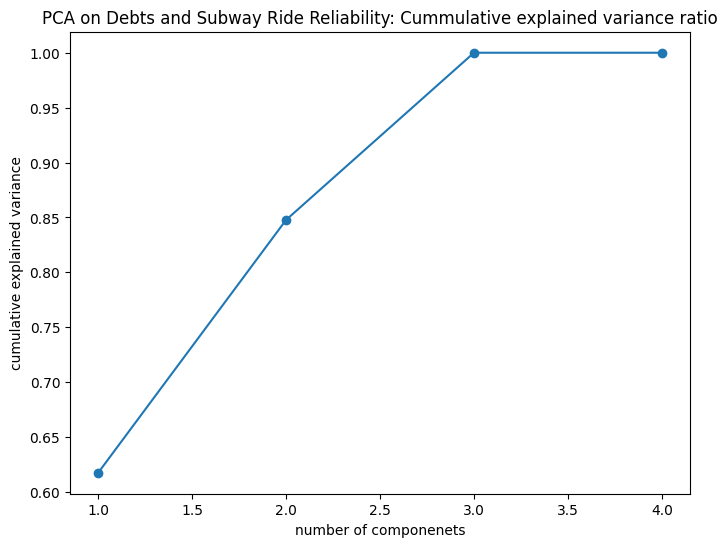

In [49]:
#code re-used from DSAN 5000 lab 4.2
#debts dataset
#get explained variance ratio
debts_evr = pca_debts.explained_variance_ratio_
debts_tevr = np.cumsum(pca_debts.explained_variance_ratio_)
print("Explained variance ratio: ", debts_evr)

#get total variance explained
print("Total explained variance", debts_tevr)

#create scatter plot that visualized the number of components and explained variance ratio to find optimal number of principal componenets 
plt.figure(figsize=(8,6)) #set plot size
plt.plot(np.arange(1, len(debts_evr) + 1), debts_evr, marker='o') #plot pca.explained_variance_ratio, set the x-axis value as array of integers
plt.title("PCA on Debts and Subway Ride Reliability: Explained variance ratio")
plt.xlabel("number of componenets") #set x-axis label
plt.ylabel("explained variance ratio") #set y-axis label
plt.show() #show plot

#create scatter plot to visualize cummulative explained variance
plt.figure(figsize=(8,6)) #set plot size
plt.plot(np.arange(1,len(debts_tevr) + 1), debts_tevr, marker='o') #plot np.cumsum(pca.explained_variance_ratio_), set the x-axis value as array of integers
plt.title("PCA on Debts and Subway Ride Reliability: Cummulative explained variance ratio")
plt.xlabel("number of componenets") #set x-axis label
plt.ylabel("cumulative explained variance") #set y-axis label
plt.show() #show plot

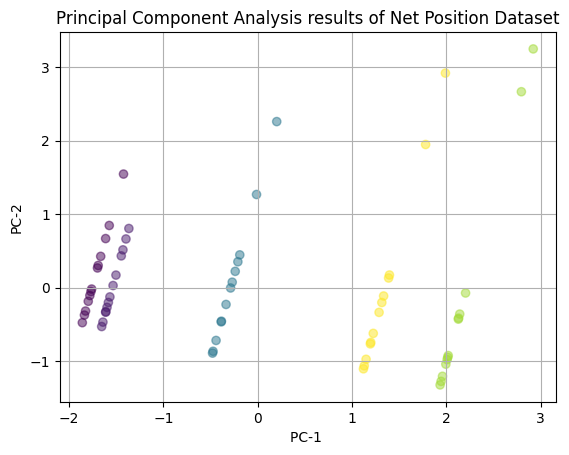

In [54]:
#code re-used from DSAN 5000 lab 4.2
#plot pca applied to the standardized net position dataset
# visualize the results
color_vector = X_netposition["ontime_trip_count"]
fig, ax = plt.subplots()
ax.scatter(X_netposition_pca[:,0], X_netposition_pca[:,1], c=color_vector, alpha=0.5)
ax.set(xlabel='PC-1 ', ylabel='PC-2',
title='Principal Component Analysis results of Net Position Dataset')
ax.grid()
plt.show()

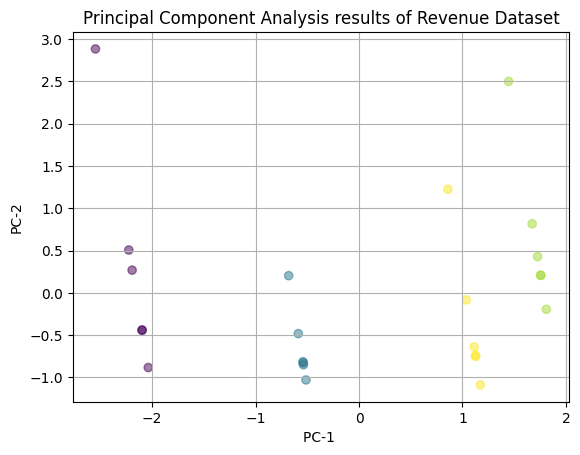

In [55]:
#code re-used from DSAN 5000 lab 4.2
#plot pca applied to the standardized revenue dataset
#visualize the results
color_vector_rev = X_rev["ontime_trip_count"]
fig_rev, ax_rev = plt.subplots()
ax_rev.scatter(X_rev_pca[:,0], X_rev_pca[:,1],c= color_vector_rev, alpha=0.5)
ax_rev.set(xlabel='PC-1 ', ylabel='PC-2',
title='Principal Component Analysis results of Revenue Dataset')
ax_rev.grid()
plt.show()

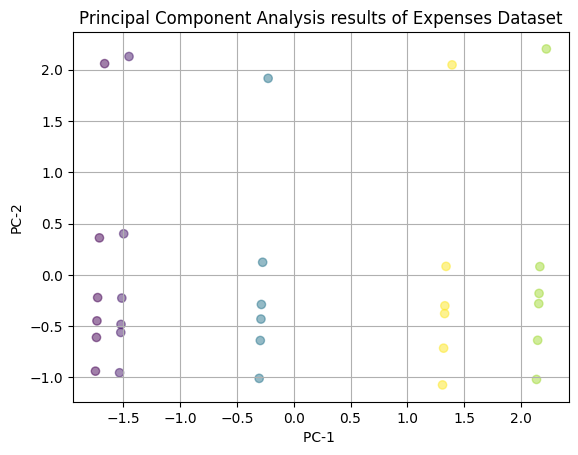

In [56]:
#code re-used from DSAN 5000 lab 4.2
#plot pca applied to the standardized expenses dataset
#visualize the results
color_vector_exp = X_exp["ontime_trip_count"]
fig_exp, ax_exp = plt.subplots()
ax_exp.scatter(X_exp_pca[:,0], X_exp_pca[:,1],c = color_vector_exp, alpha=0.5)
ax_exp.set(xlabel='PC-1 ', ylabel='PC-2',
title='Principal Component Analysis results of Expenses Dataset')
ax_exp.grid()
plt.show()

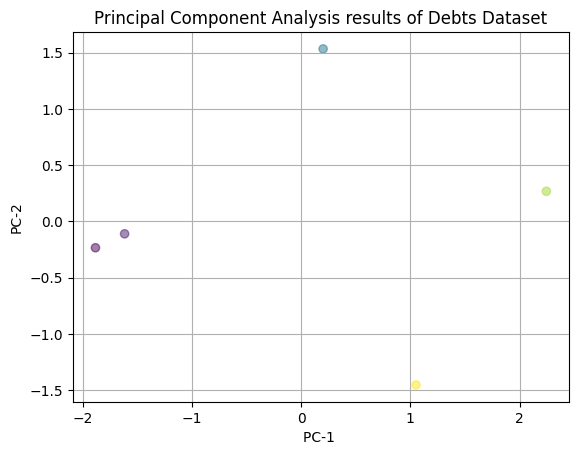

In [57]:
#code re-used from DSAN 5000 lab 4.2
#plot pca applied to the standardized debts dataset
#visualize the results
color_vector_debt = X_debts["ontime_trip_count"]
fig_debts, ax_debts = plt.subplots()
ax_debts.scatter(X_debts_pca[:,0], X_debts_pca[:,1],c = color_vector_debt, alpha=0.5)
ax_debts.set(xlabel='PC-1 ', ylabel='PC-2',
title='Principal Component Analysis results of Debts Dataset')
ax_debts.grid()
plt.show()

### t-SNE (t-distributed Stochastic Neighbor Embedding):

(65, 3)


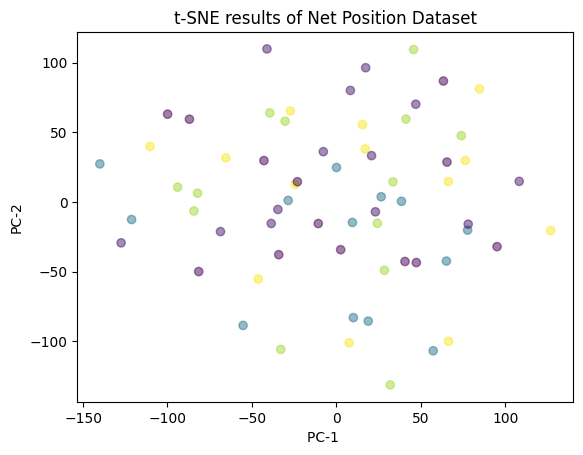

In [63]:
#code re-used from DSAN 5000 lab 4.2
#import sklearn library for TSNE
from sklearn.manifold import TSNE

#apply t-sne to the net position dataset
tsne = TSNE(n_components=3) #3 features
netposition_tsne = tsne.fit_transform(X_netposition) #fit tsne onto net position data
print(netposition_tsne.shape) #get shape of tsne transformed net position data

#visualize the tsne results
color_vector_net_tsne = X_netposition["ontime_trip_count"] #group data points by color using "ontime_trip_count" column
fig_net_tsne, ax_net_tsne = plt.subplots()
ax_net_tsne.scatter(netposition_tsne[:,0], netposition_tsne[:,1],c= color_vector_net_tsne, alpha=0.5)
ax_net_tsne.set(xlabel='PC-1 ', ylabel='PC-2',
title='t-SNE results of Net Position Dataset')
ax_rev.grid()
plt.show()


(24, 3)


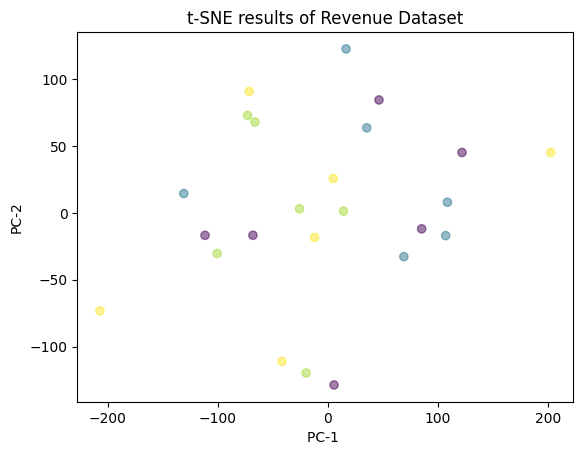

In [72]:
#code re-used from DSAN 5000 lab 4.2

#apply t-sne to the revenue dataset
rtsne = TSNE(n_components=3, perplexity=1) #3 features
revenue_tsne = rtsne.fit_transform(X_rev) #fit tsne onto revenue data
print(revenue_tsne.shape) #get shape of tsne transformed revenue data

#visualize the tsne results on the revnue
color_vector_rev_tsne = X_rev["ontime_trip_count"] #group data points by color using "ontime_trip_count" column
fig_rev_tsne, ax_rev_tsne = plt.subplots()
ax_rev_tsne.scatter(revenue_tsne[:,0], revenue_tsne[:,1],c= color_vector_rev_tsne, alpha=0.5)
ax_rev_tsne.set(xlabel='PC-1 ', ylabel='PC-2',
title='t-SNE results of Revenue Dataset')
ax_rev.grid()
plt.show()


(30, 3)


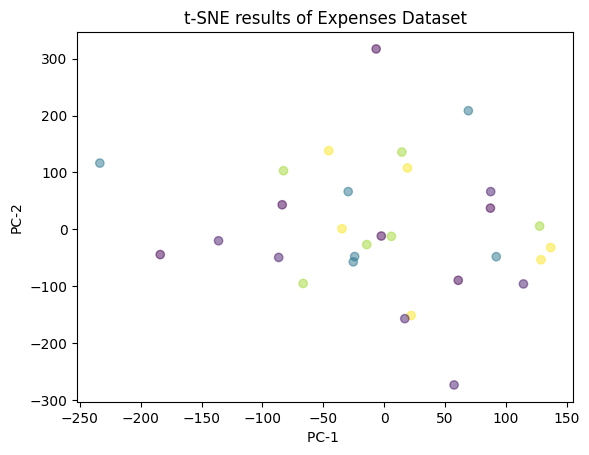

In [74]:
#code re-used from DSAN 5000 lab 4.2

#apply t-sne to the expenses dataset
etsne = TSNE(n_components=3, perplexity=1) #3 features
exp_tsne = etsne.fit_transform(X_exp) #fit tsne onto expenses data
print(exp_tsne.shape) #get shape of tsne transformed expenses data

#visualize the tsne results on the expenses
color_vector_exp_tsne = X_exp["ontime_trip_count"] #group data points by color using "ontime_trip_count" column
fig_exp_tsne, ax_exp_tsne = plt.subplots()
ax_exp_tsne.scatter(exp_tsne[:,0], exp_tsne[:,1],c= color_vector_exp_tsne, alpha=0.5)
ax_exp_tsne.set(xlabel='PC-1 ', ylabel='PC-2',
title='t-SNE results of Expenses Dataset')
ax_exp.grid()
plt.show()

(5, 3)


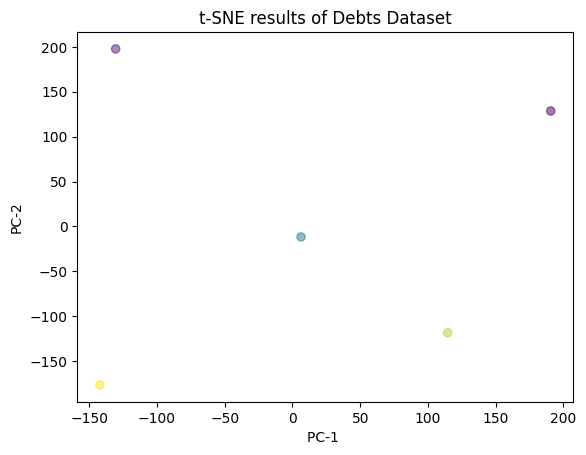

In [79]:
#code re-used from DSAN 5000 lab 4.2

#apply t-sne to the debts dataset
dtsne = TSNE(n_components=3, perplexity=1) #3 features
debts_tsne = dtsne.fit_transform(X_debts) #fit tsne onto debts data
print(debts_tsne.shape) #get shape of tsne transformed debts data

#visualize the tsne results on the debts
color_vector_debts_tsne = X_debts["ontime_trip_count"] #group data points by color using "ontime_trip_count" column
fig_debts_tsne, ax_debts_tsne = plt.subplots()
ax_debts_tsne.scatter(debts_tsne[:,0], debts_tsne[:,1],c= color_vector_debts_tsne, alpha=0.5)
ax_debts_tsne.set(xlabel='PC-1 ', ylabel='PC-2',
title='t-SNE results of Debts Dataset')
ax_debts.grid()
plt.show()

### Evaluation and Comparison:

When comparing the PCA plots and the t-sne plots of the net position, expenses, revenues, and debts amount regarding the MBTA system, it appears that the PCA plots had more effectiveness in classifying the data points into distinct groups/ clusters than the application of t-sne.
The calculated explained variance and the total explained variance of the PCA application were high, which tells us that large amounts of information were captured by the principal components.
The PCA plots show distinct grouping of data points that are color labeld by target variable = number of trips on time. The distinct clustering shows that those data points in the same cluster were more similar to each other compared to other data points in other clusters.

The t-sne plots do not show distinct clusters and the data points are more separate from each other. We can interpret the spread out of the data points in the t-sne plots that there are more differences of the data points within the same cluster/ group. There were no distinct clustering of the net position, expenses, revenues, amount, and on - time trip features.


## Clustering Methods:

In [85]:
#create new dataframe of the standardized features in the net position , revenue, expenses, and debts dataset
X_netposition_scaled2 = pd.DataFrame(X_netposition_scaled, columns=X_netposition.columns)
X_rev_scaled2 = pd.DataFrame(X_rev_scaled, columns=X_rev.columns)
X_exp_scaled2 = pd.DataFrame(X_exp_scaled, columns=X_exp.columns)
X_debt_scaled2 = pd.DataFrame(X_debts_scaled, columns=X_debts.columns)


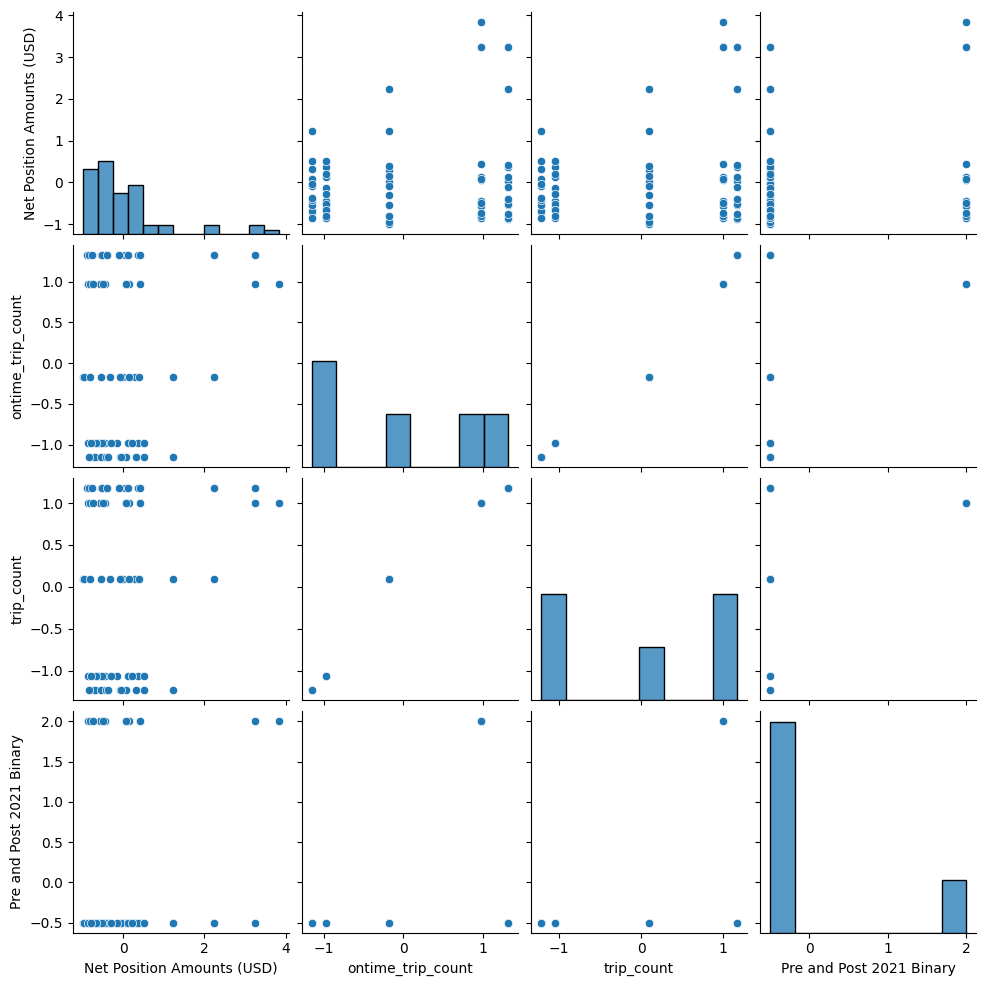

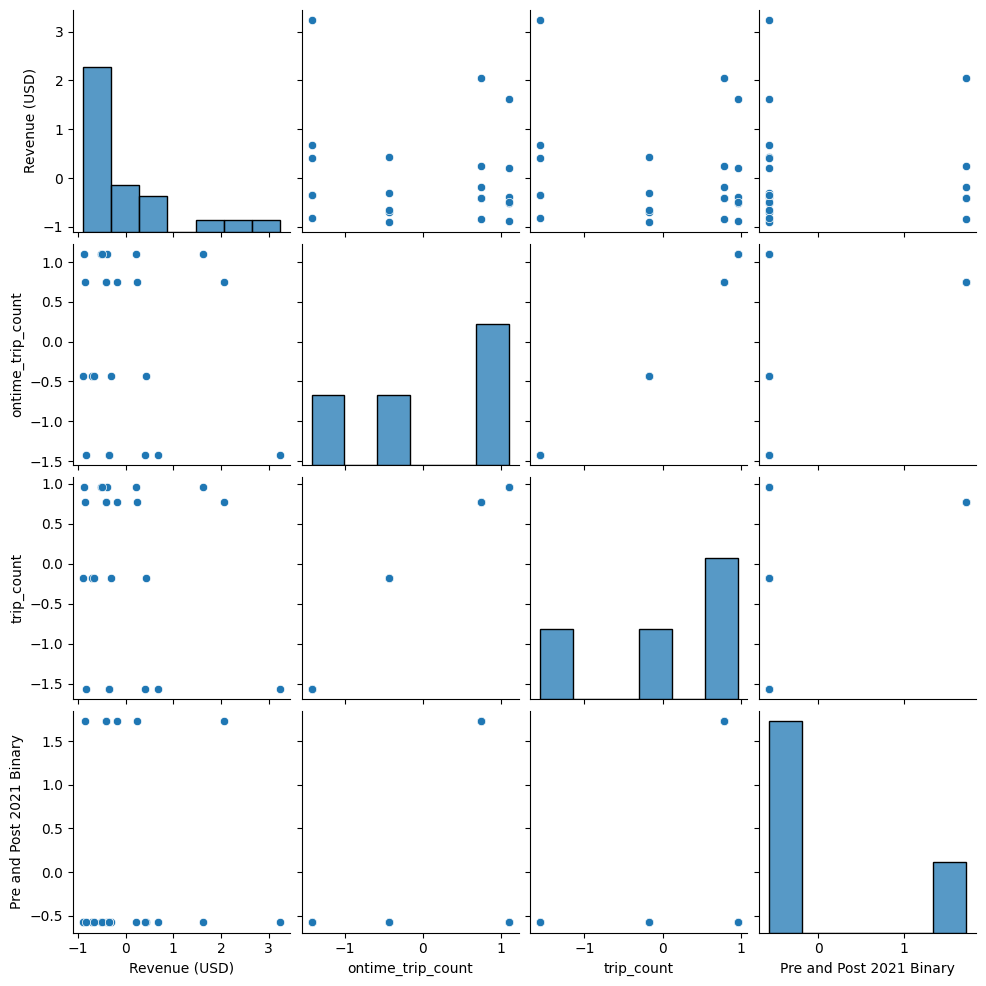

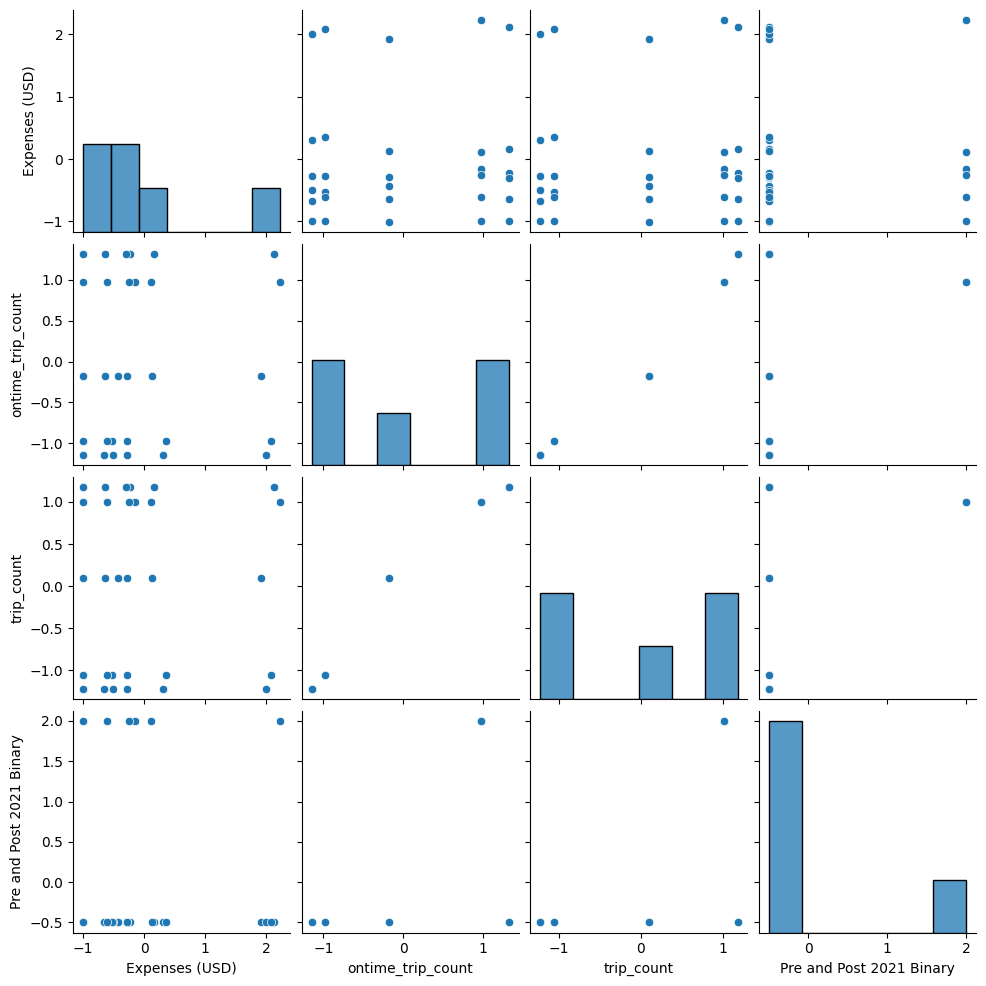

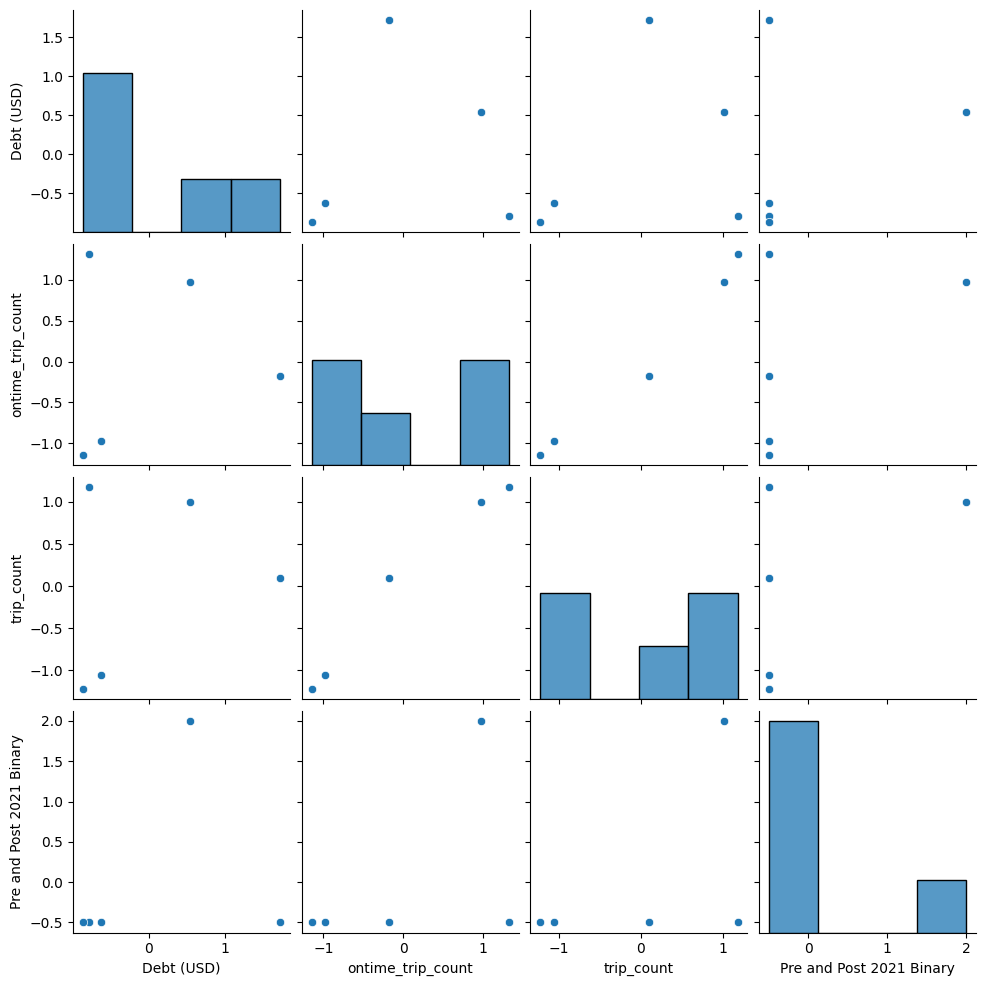

In [86]:
#create pairplots of scaled net position , revenue, expenses, and debts dataset
sns.pairplot(X_netposition_scaled2) #create pairplot for net position dataset
plt.show() #show pairplot

sns.pairplot(X_rev_scaled2) #create pairplot for revenue dataset
plt.show() #show pairplot

sns.pairplot(X_exp_scaled2) #create pairplot for expenses dataset
plt.show() #show pairplot

sns.pairplot(X_debt_scaled2) #create pairplot for debts dataset
plt.show() #show pairplot

### kmeans clustering method:

In [87]:
#subset the debts dataset, select only the Debt (USD) and the ontime_trip count columns
df_debts_subset = X_debt_scaled2[["Debt (USD)", "ontime_trip_count"]]


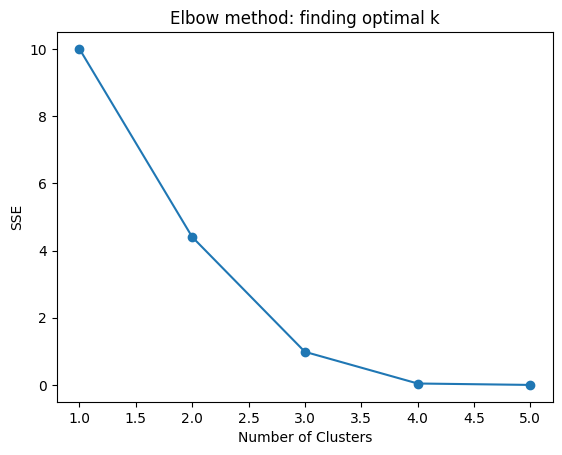

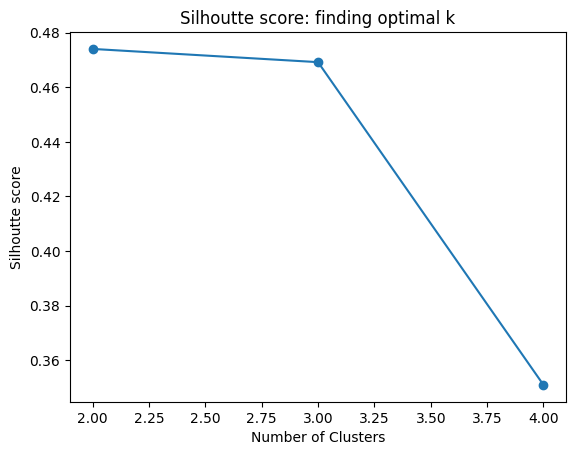

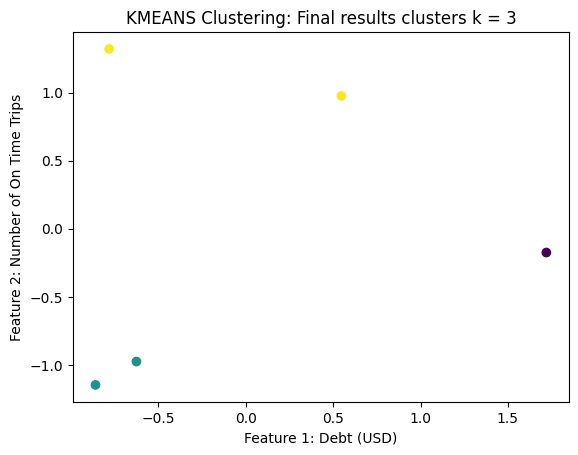

In [94]:
#code re-used from dsan5000 lab 4.1

#import Scikit-learn modules
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score


#use Elbow method on debts dataset to find the best k value.
#initialize parameters for kmeans
kmeans_param = {"init": "random", #initialize cluster centers randomly
"n_init": 10, #iterate through k means algorithm for 10 initializations
 "random_state": 1,} #random number generator for cluster centers

sse = [] #initialize empty list to store sse = sum of squared errors for each k

n_samples = df_debts_subset.shape[0]
#iterate through the values of k from 1 to n
for k in range(1, min(11, n_samples + 1)):
    kmeanModel = KMeans(n_clusters=k, **kmeans_param) #build model using kMeans
    kmeanModel.fit(df_debts_subset) #fit the model to the scaled debts data
    sse.append(kmeanModel.inertia_) #append model to the sse list

plt.plot(range(1,n_samples + 1), sse, marker='o') #plot the results vs. k to find the "elbow-point"
plt.title("Elbow method: finding optimal k") #set title for the plot
plt.xlabel("Number of Clusters") #set label for x-axis
plt.ylabel("SSE") #set label for y-axis
plt.show() #show plot

#use the Silhoutte score:
range_clusters = list(range(2,5)) #start with 2 to iterate over each k, limit to 5 due to the debts dataset only having n_clusters = 5
scores = [] #initialize empty list to store the silhoutte score
for n_clusters in range_clusters: #iterate though values of k to find optimal number of clusters
    cluster = KMeans(n_clusters=n_clusters) #build model
    p = cluster.fit_predict(df_debts_subset) #fit the model to the scaled penguins data
    score = silhouette_score(df_debts_subset, p) #calculate the silhoutte score for each k in the same range
    scores.append(score) #append silhoutte scores to the scores list

plt.plot(range_clusters, scores, marker='o') #plot the silhoutte score vs. k
plt.title("Silhoutte score: finding optimal k") #set title for the plot
plt.xlabel("Number of Clusters") #set label for x-axis
plt.ylabel("Silhoutte score") #set label for y-axis
plt.show() #show plot

#Final result
#based on the elbow point plot and the Silhoutte score plot, optimal k = 3
optimal_k = 3
finalkmeanModel = KMeans(n_clusters=optimal_k, **kmeans_param) #build model
cluster_labels = finalkmeanModel.fit_predict(df_debts_subset) #fit the model on to the scaled penguins data

plt.scatter(df_debts_subset['Debt (USD)'], df_debts_subset['ontime_trip_count'], c=cluster_labels, marker='o') #create scatter plot result of attributes 'Debt (USD)' and 'ontime_trip_count'
plt.title("KMEANS Clustering: Final results clusters k = 3") #set plot title
plt.xlabel("Feature 1: Debt (USD)") #set label for x-axis
plt.ylabel("Feature 2: Number of On Time Trips") #set label for y-axis
plt.show() #show plot


The k-means algorithm works by choosing the number of clusters, which is k and selects centroids that are the center of each cluster. The algorithm assigns data points to the centroid closest to them and uses Euclidean distance to calculate which centroid is closer to the data point. Then k-means iterates over the centroids and re-calculates all the data points until the centroids stops changing.

Purpose of k-means is to find the data points that are similar to each other and group them together in clusters.

The elbow method and silhoutte score plots shows the optimal k is at 3.

The k-means clustering with k = 3 scatter plot shows the clusters that were computed on the debts dataset. The plot shows three distinct colored groups but the data points are more spreadout. The result implies there are not many data points that share similarity in the debts dataset.

### DBSCAN Clustering:

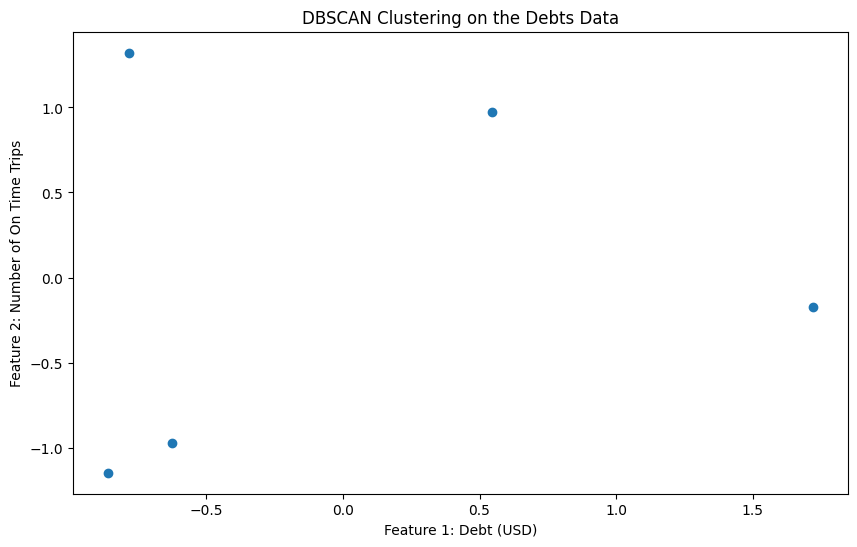

In [96]:
#code re-used from dsan5000 lab 4.1

#standardize the debts features
dstandardized = StandardScaler().fit_transform(df_debts_subset)

#set eps = 3 and min_samples = 3 because k=3 was used for the final results of k means model and final scatter plot showed 3 clusters
#initialize DBSCAN with the chosen parameters
clustering = DBSCAN(eps=3, min_samples=3).fit(dstandardized)

#fit the model and predict cluster labels
clusters = clustering.labels_

#set labels to mark noise points
labels = set(clusters)

#plot the clusters
plt.figure(figsize=(10,6)) #set figure size
for dot in labels: #iterate over noise points
    if dot == -1: #check condition, set up noise with -1 as label for feature 1 and feature 2
        plt.scatter(dstandardized[clusters == dot, 0], dstandardized[clusters == dot, 1], c='red', label='Noise')
    else: #if label does not meet noise condition, then it is a cluster label
        plt.scatter(dstandardized[clusters == dot, 0], dstandardized[clusters == dot, 1], label=f'Cluster {dot}')

plt.title('DBSCAN Clustering on the Debts Data') #set plot title
plt.xlabel("Feature 1: Debt (USD)") #set label for x-axis
plt.ylabel("Feature 2: Number of On Time Trips") #set label for y-axis
plt.show() #show plot

The DBSCAN clustering algorithm works by first finding neighbors in the data points by calculating the distances and knowing what the least number of data points are needed for a cluster so it know when to assign an outlier data point as a noise.
Then the algorithm the centers of the clusters and expands the cluster. Afterwards, the algorithm identifies the border data points and the noise data points. This process is repeated until all the data points have been assigned as either a core point (center of cluster), a border point, or a noise.

Purpose of DBSCAN is to find clusters within datasets without knowing beforehand how many clusters will be formed. This can help find odd-shaped clusters and find outliers in the dataset.

The DBSCAN plot above shows application of DBSCAN clustering on debt (USD) amount vs number of MBTA subway trips on time. The data points are spread out far, there are no distinct cluster groups and no outliers identified. This implies DBSCAN application of the debts dataset was not the best method since no clusters were formed.

### Hierarchical clustering method:

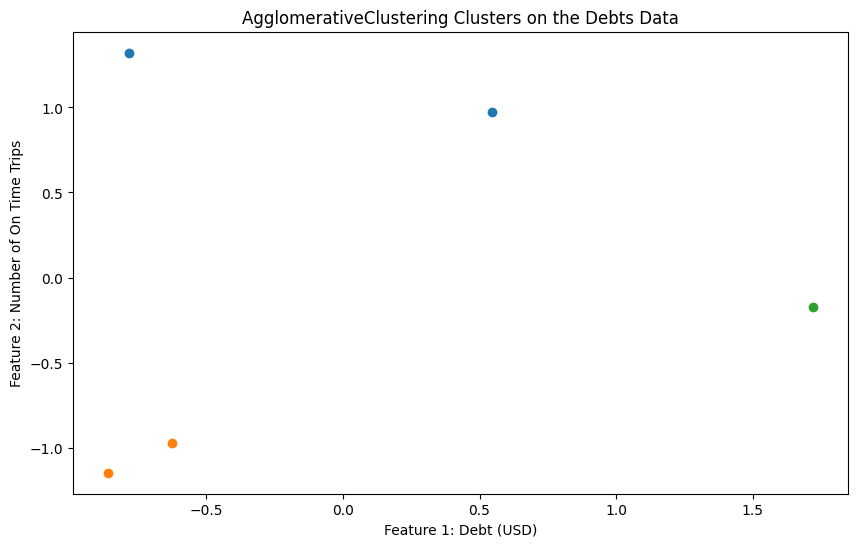

In [98]:
#code re-used from dsan5000 lab 4.1

#initialize agglomerative clustering for hierarchical clustering with the chosen parameters
agg_model = AgglomerativeClustering(n_clusters=3)

#fit the model and predict cluster labels
agg_fit = agg_model.fit_predict(dstandardized)

#set labels for cluster points
agg_labels = set(agg_fit)

#plot the clusters
plt.figure(figsize=(10,6)) #set figure size
#loops through each label to be plot in scatter plot
for label in agg_labels:
    plt.scatter(dstandardized[agg_fit == label, 0], dstandardized[agg_fit == label, 1])

plt.title('AgglomerativeClustering Clusters on the Debts Data') #set plot title
plt.xlabel("Feature 1: Debt (USD)") #set label for x-axis
plt.ylabel("Feature 2: Number of On Time Trips") #set label for y-axis
plt.show()


The Agglomerative Hierarchical clustering works by first setting each data point as its own cluster. Then the algorithm calculates the distance between each cluster, then combines the clusters that are close together. This process repeats until all the datapoints are put into the same cluster.

The purpose of the Agglomerative Hierarchical clustering is to group data points and it is more useful when you do not know how many groups there will be formed. It is also useful to find relationships in the dataset.

The scatter plot above shows the application of Agglomerative Hierarchical clustering on the Debts (usd) amounts vs. number of on time MBTA subway trips. The data points are very spread out and there are only two distinctly colored groups: orange and blue. This implies the data point with similar colors are more similar to each other than to the other colored cluster.

## Conclusion/ Discussion of clustering methods: 

In conclusion, the application of the kmeans clustering and the Agglomerative Hierarchical clustering methods were the best methods to be used on the debts dataset. This is because those two algorithms were able to find two to three clusters in the debts dataset. Which means the algorithms were able to uncover patterns in the features of debt amount vs. number of on time MBTA subway rides. 

The results of the un-supervised learning supports further analysis can be done to investigate if the accumulation of debt over the years have a significant impact on the number of subway rides arriving on time in the MBTA system. If debt has a significant relationship with number of subway trips arriving on time, then plans to attempt reducing debt can be set in motion in order to improve the reliability and efficienty of the MBTA subway.